# Experiment 4: Binary Classification using Linear and Kernel-Based Models
To classify emails as spam or ham using Logistic Regression and Support Vector Machine (SVM) classifiers and to analyze the effect of hyperparameter tuning on classification performance.

## 1. EDA and Data Description

------------------------------------------------------------
DATASET OVERVIEW
Dimensions: (4601, 58)

First 5 rows:
   word_freq_make  word_freq_address  word_freq_all  word_freq_3d  \
0            0.00               0.64           0.64           0.0   
1            0.21               0.28           0.50           0.0   
2            0.06               0.00           0.71           0.0   
3            0.00               0.00           0.00           0.0   
4            0.00               0.00           0.00           0.0   

   word_freq_our  word_freq_over  word_freq_remove  word_freq_internet  \
0           0.32            0.00              0.00                0.00   
1           0.14            0.28              0.21                0.07   
2           1.23            0.19              0.19                0.12   
3           0.63            0.00              0.31                0.63   
4           0.63            0.00              0.31                0.63   

   word_freq_order  word

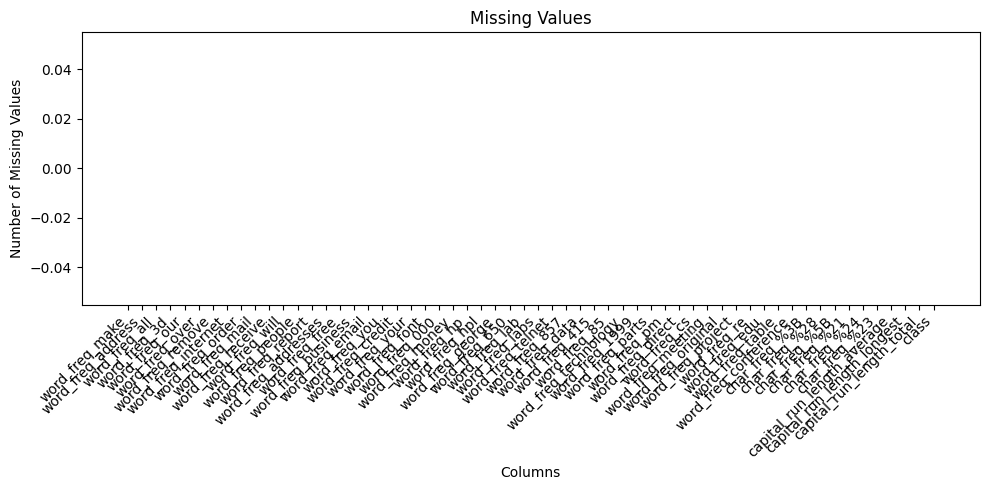


No columns have more than 50% missing values.

Numerical columns:
['word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d', 'word_freq_our', 'word_freq_over', 'word_freq_remove', 'word_freq_internet', 'word_freq_order', 'word_freq_mail', 'word_freq_receive', 'word_freq_will', 'word_freq_people', 'word_freq_report', 'word_freq_addresses', 'word_freq_free', 'word_freq_business', 'word_freq_email', 'word_freq_you', 'word_freq_credit', 'word_freq_your', 'word_freq_font', 'word_freq_000', 'word_freq_money', 'word_freq_hp', 'word_freq_hpl', 'word_freq_george', 'word_freq_650', 'word_freq_lab', 'word_freq_labs', 'word_freq_telnet', 'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_85', 'word_freq_technology', 'word_freq_1999', 'word_freq_parts', 'word_freq_pm', 'word_freq_direct', 'word_freq_cs', 'word_freq_meeting', 'word_freq_original', 'word_freq_project', 'word_freq_re', 'word_freq_edu', 'word_freq_table', 'word_freq_conference', 'char_freq_%3B', 'char_freq_%2

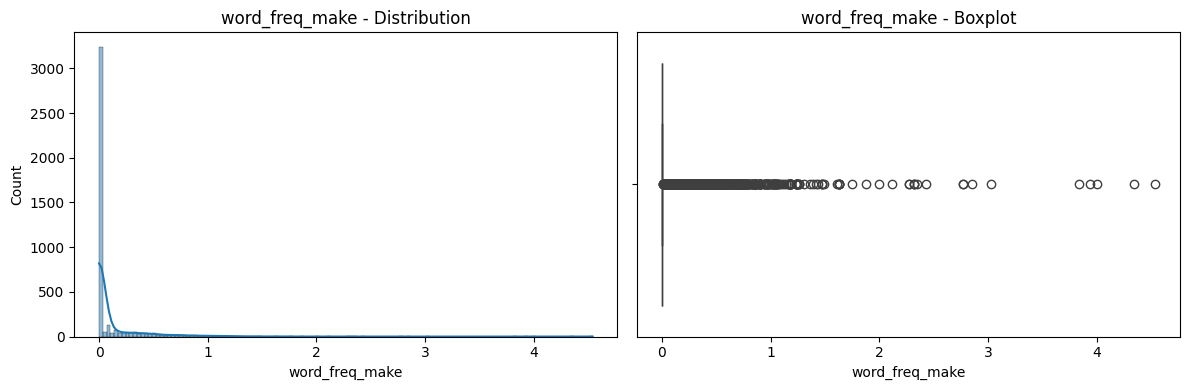

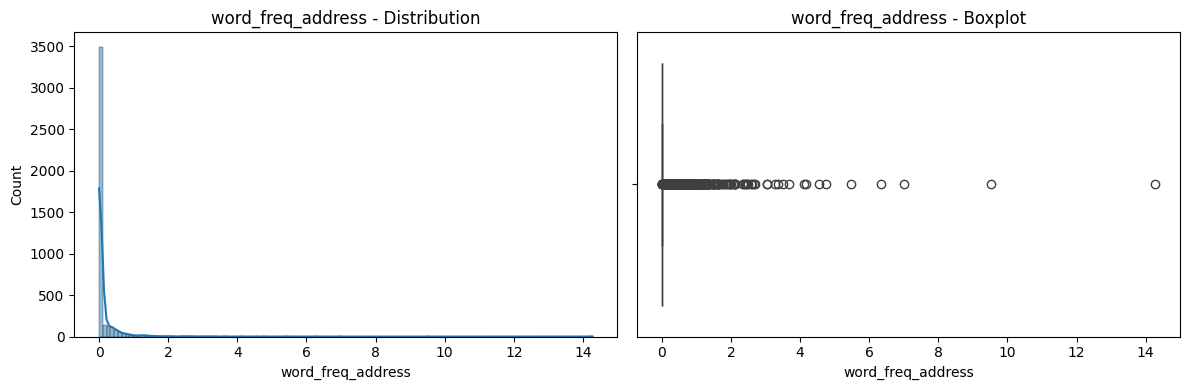

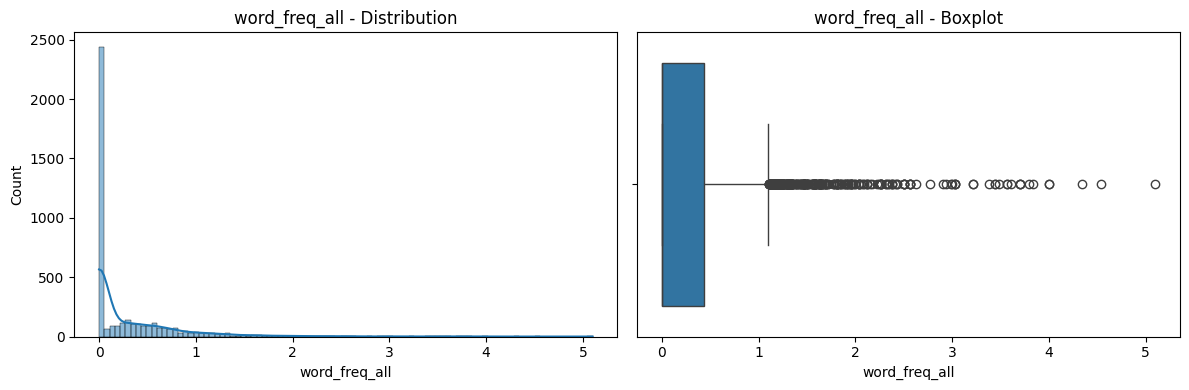

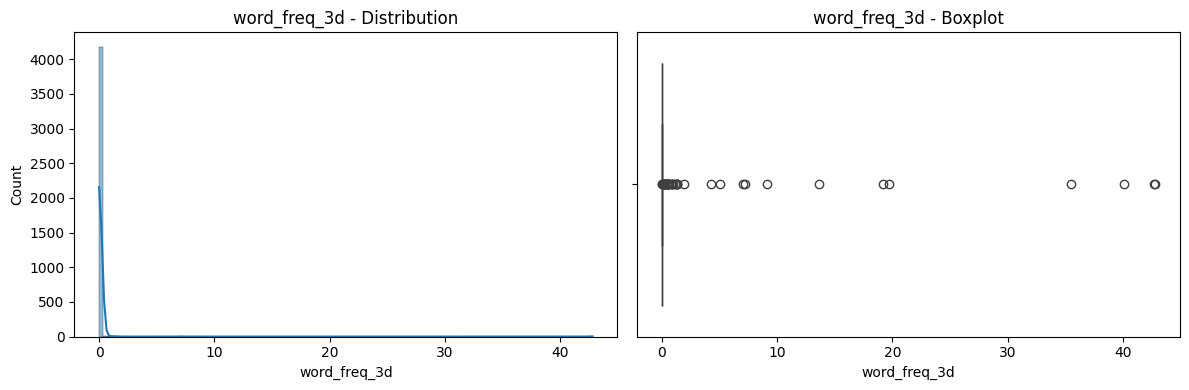

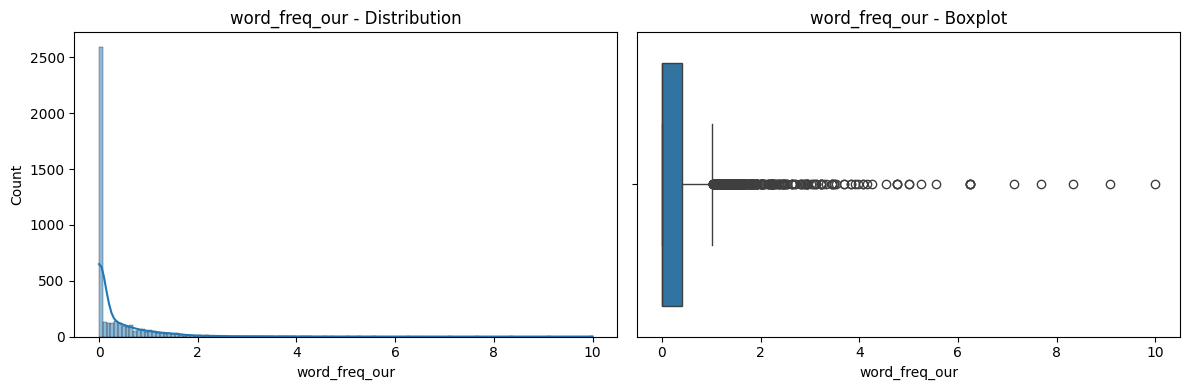

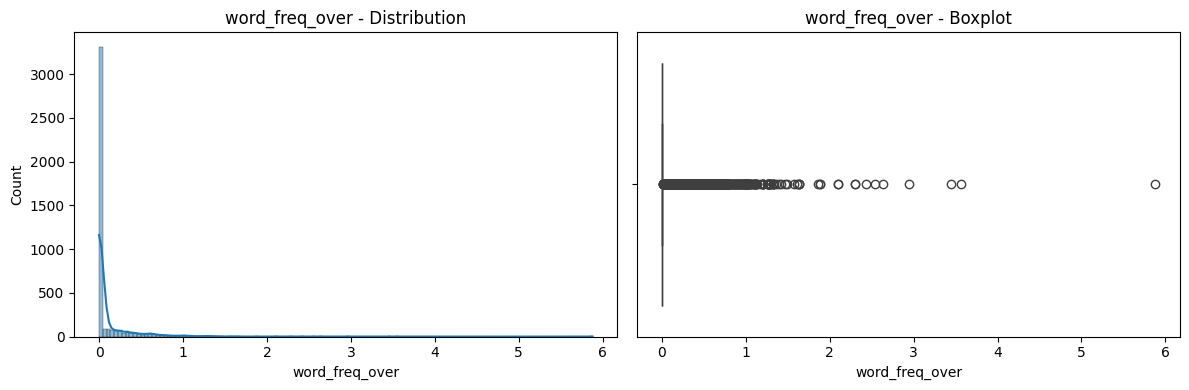

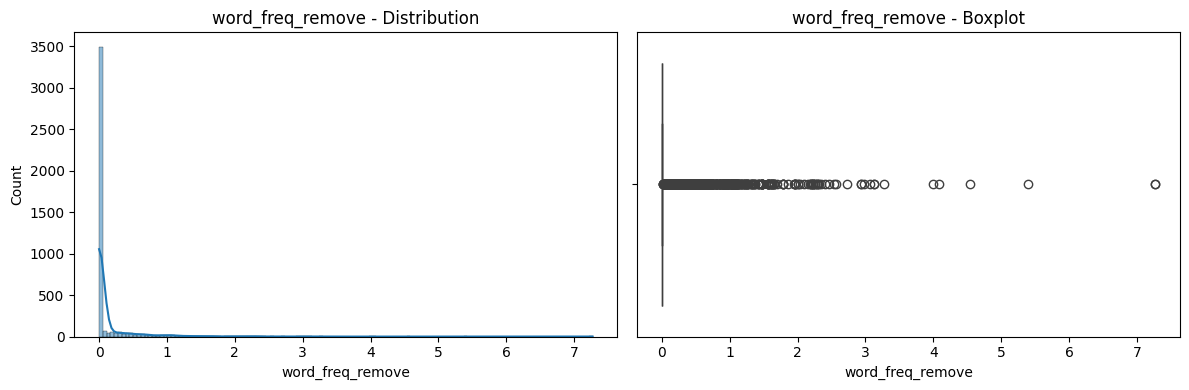

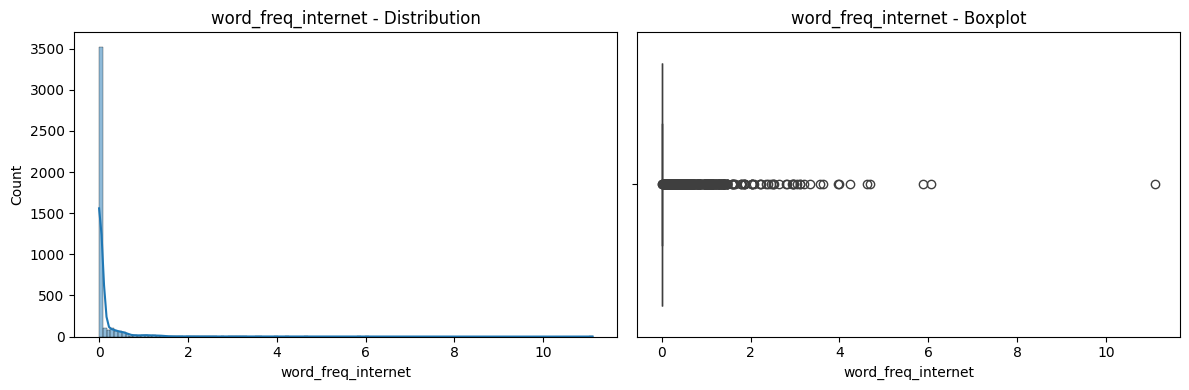

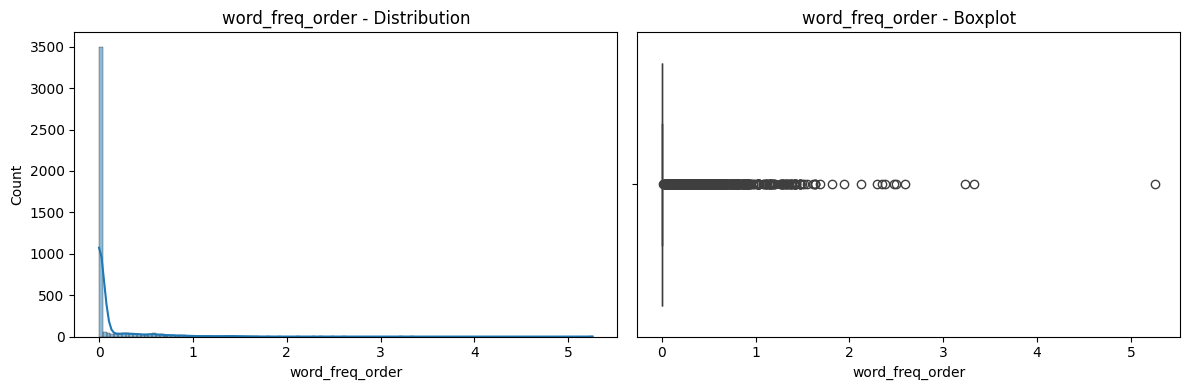

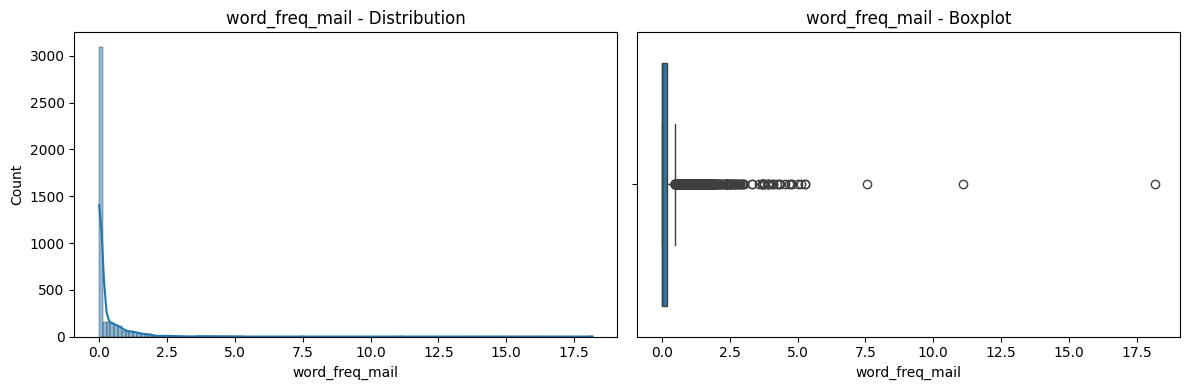

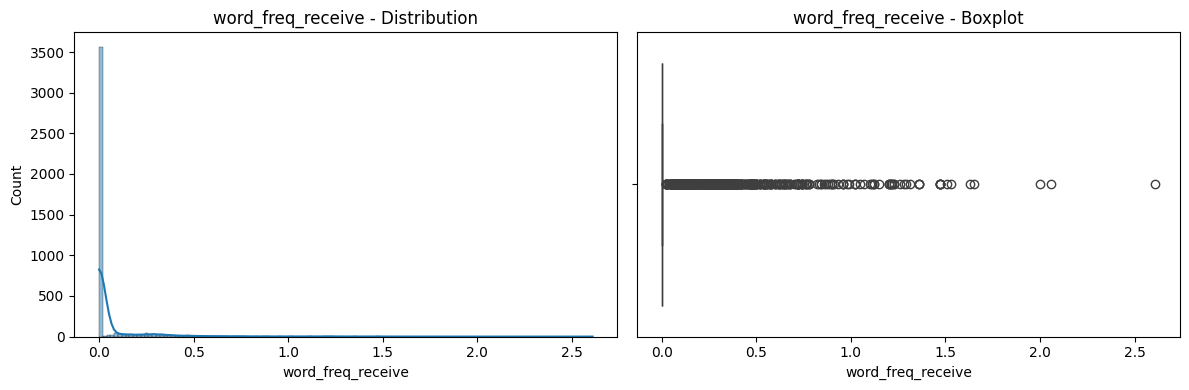

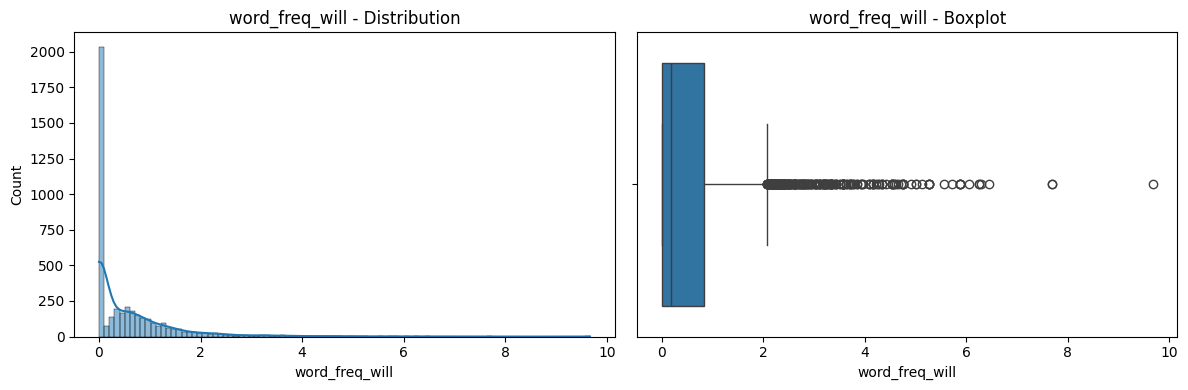

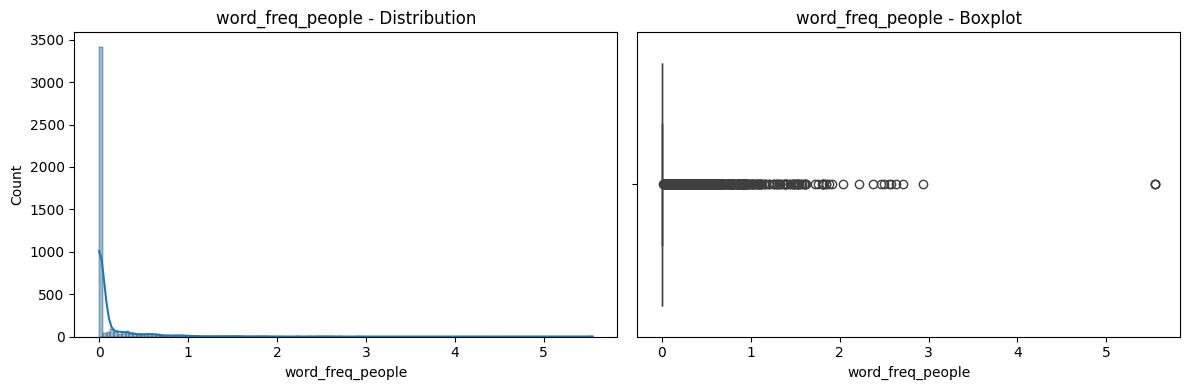

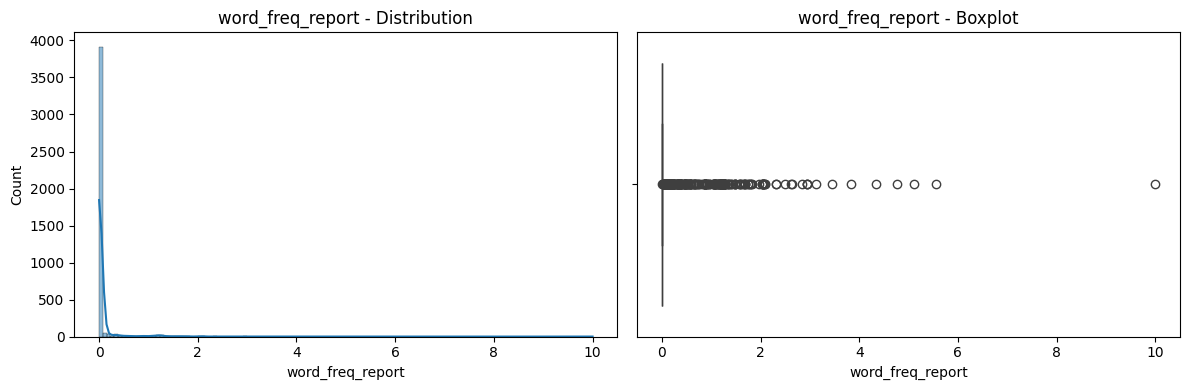

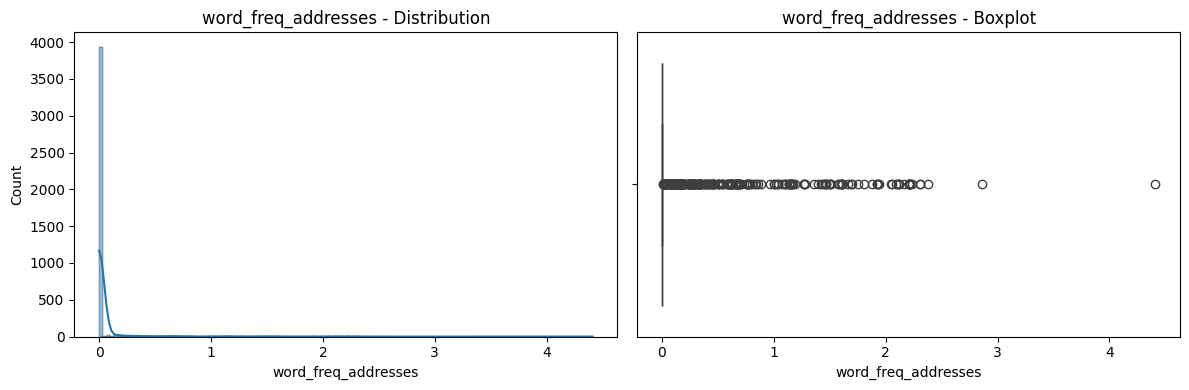

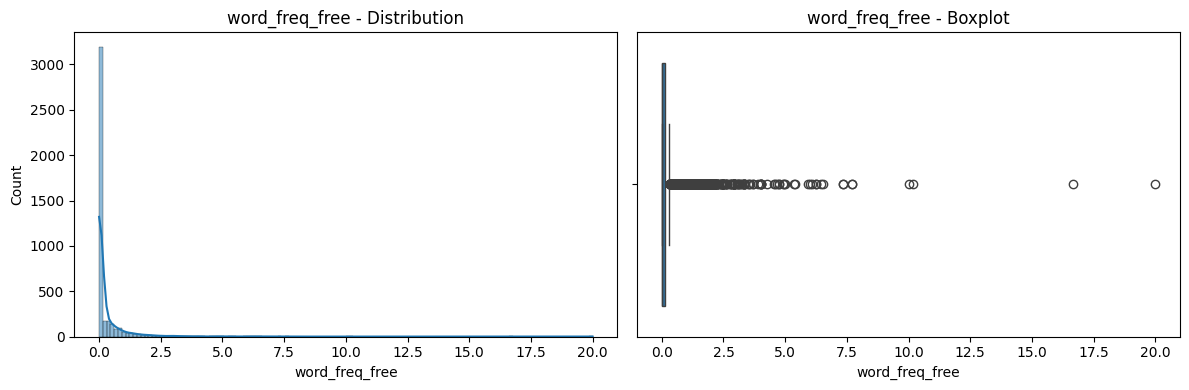

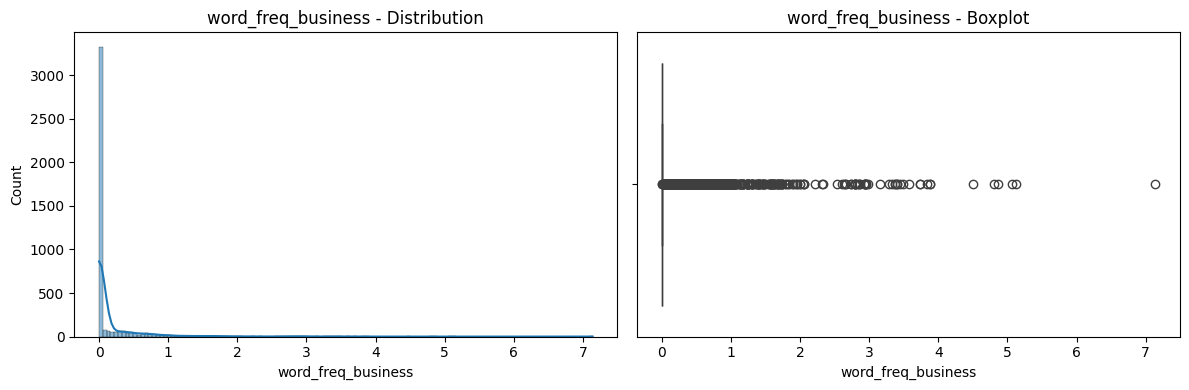

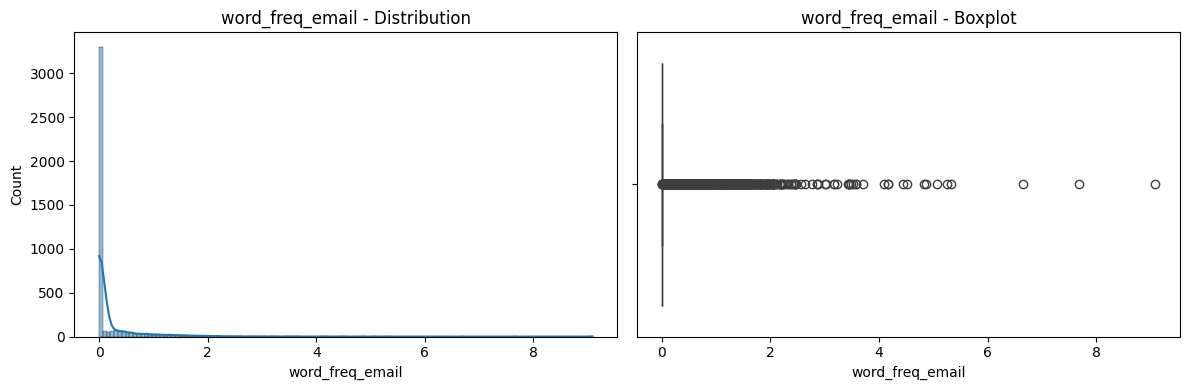

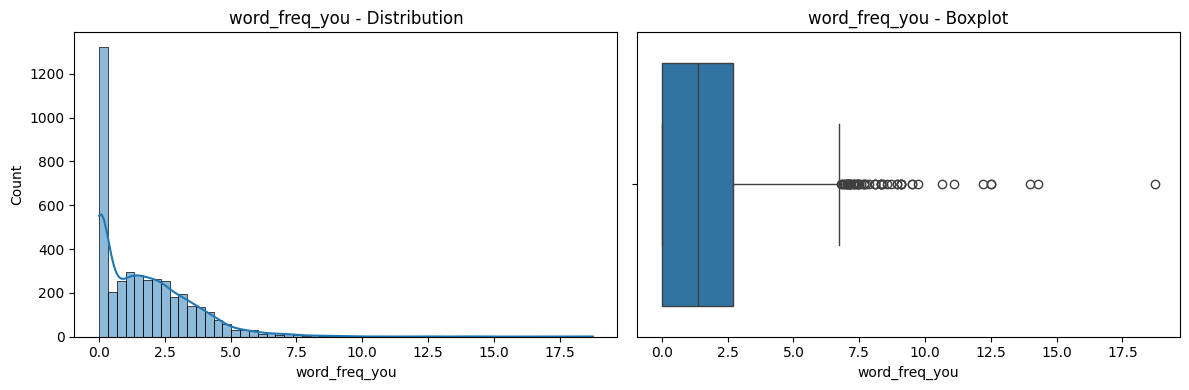

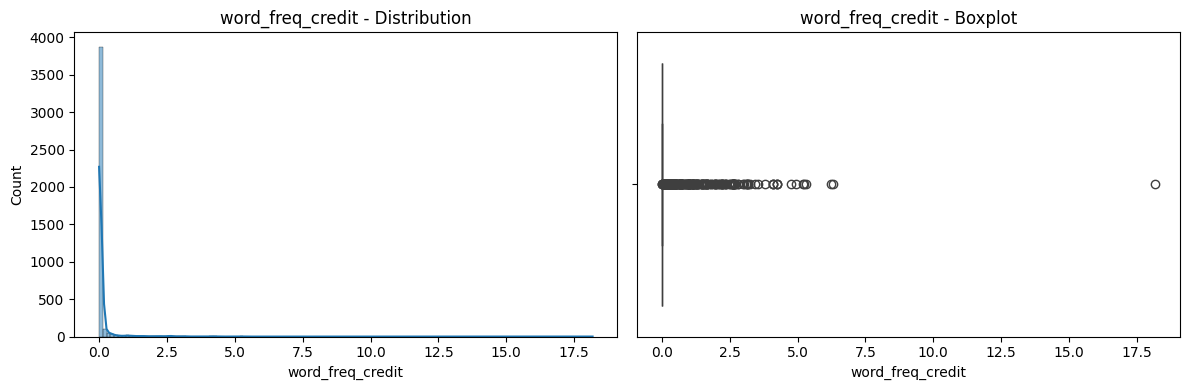

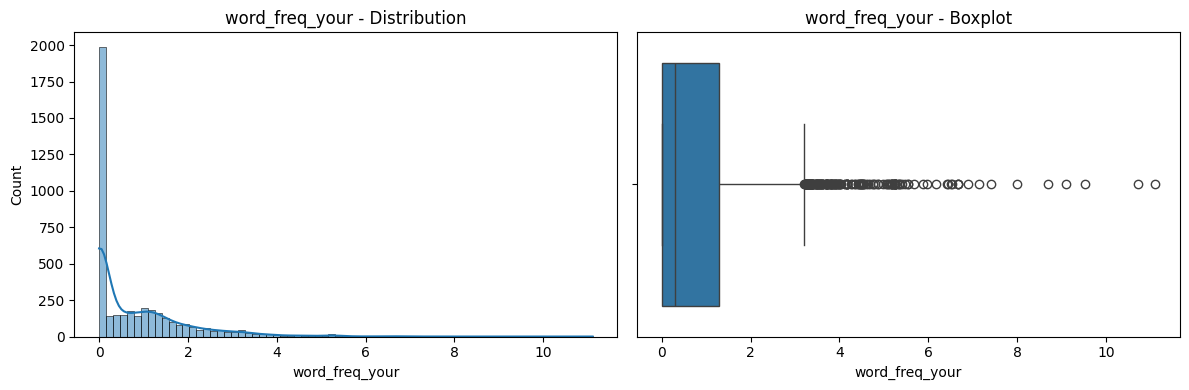

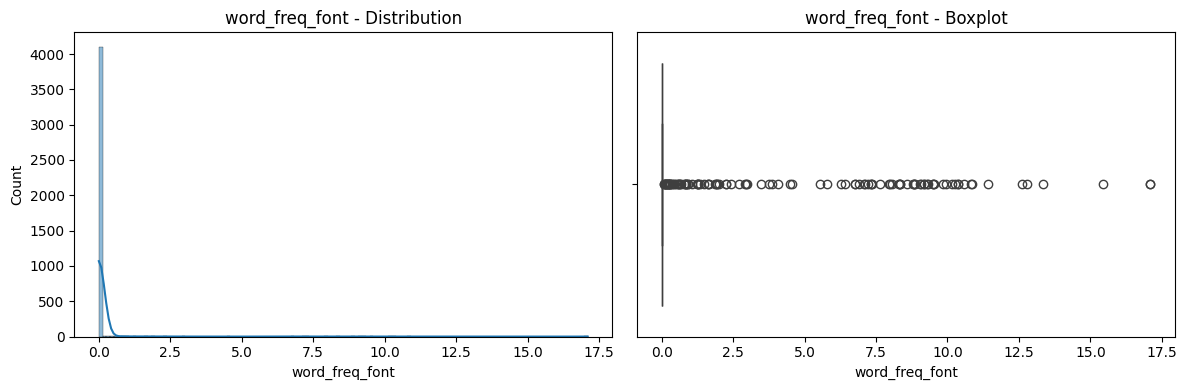

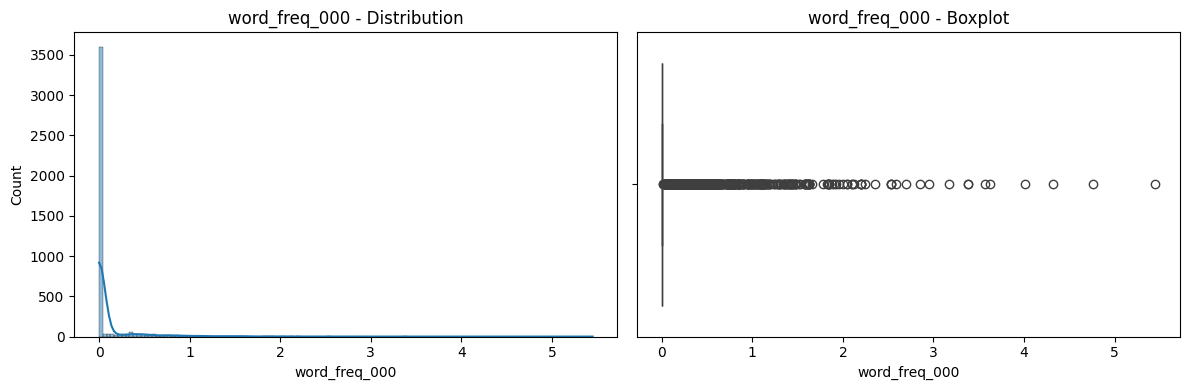

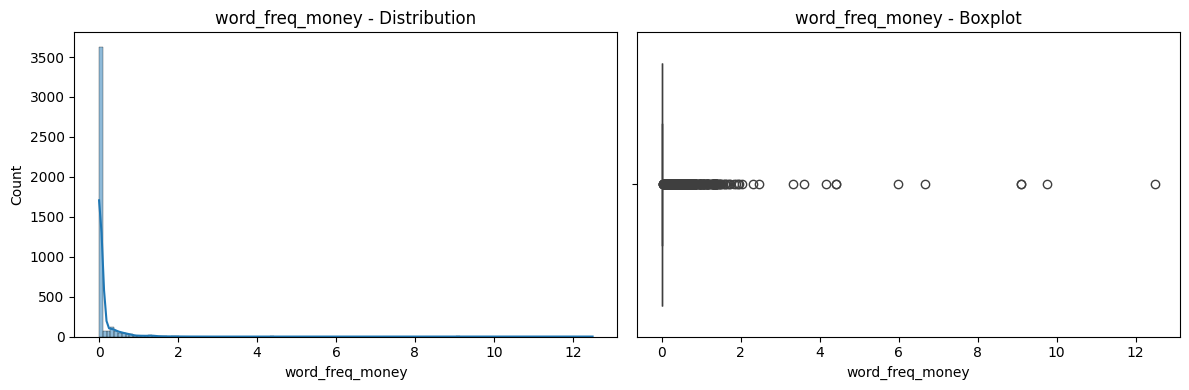

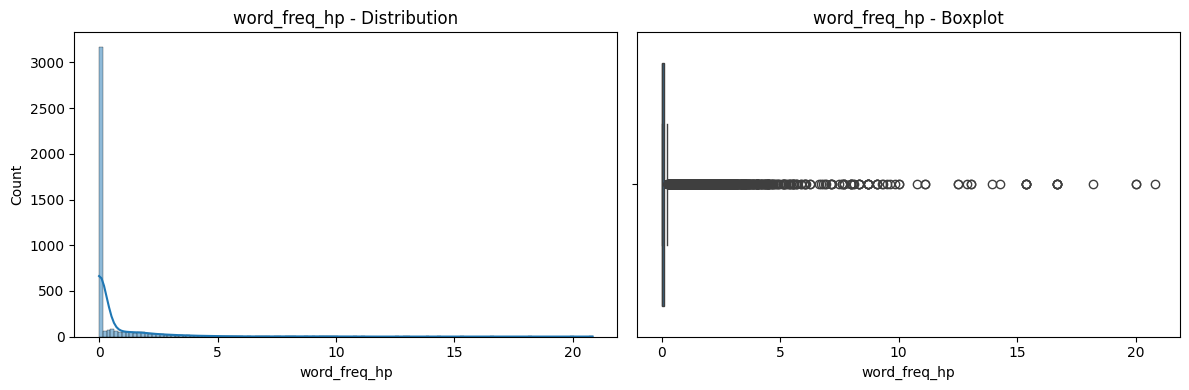

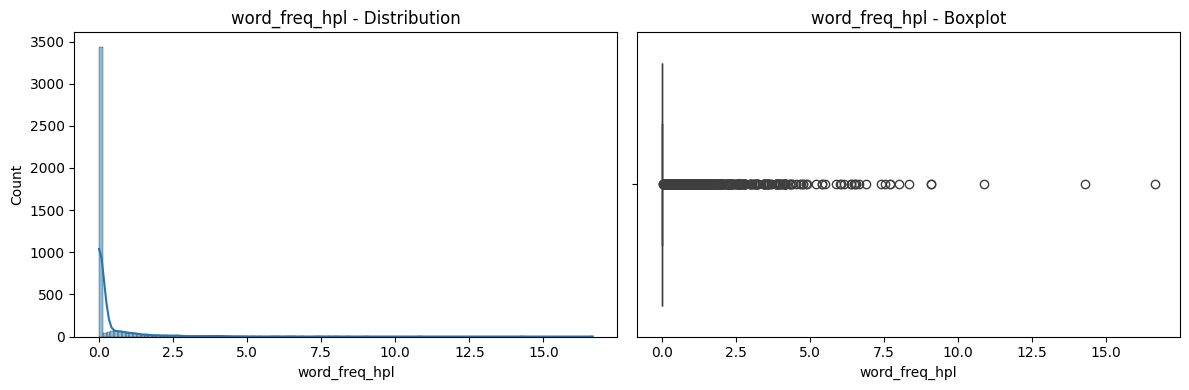

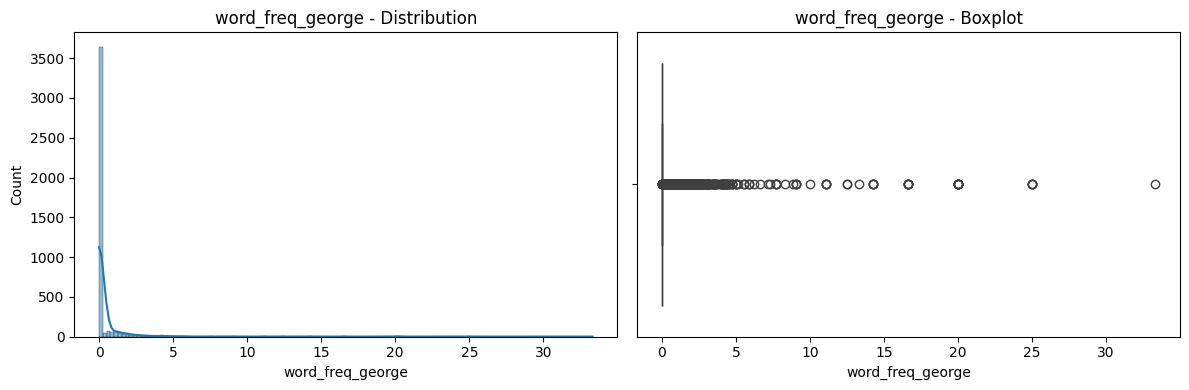

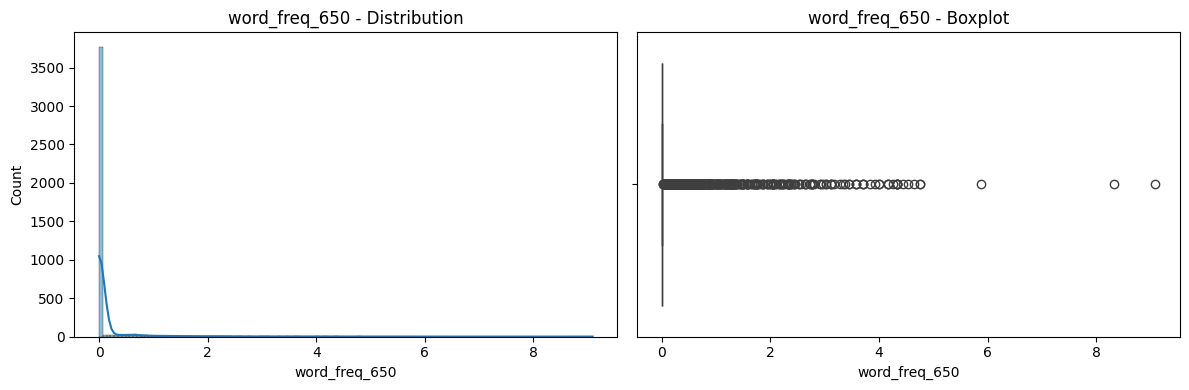

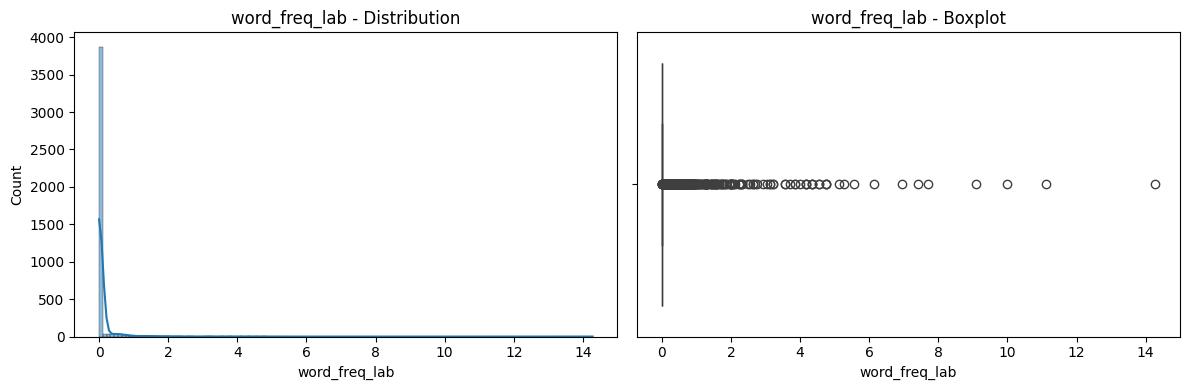

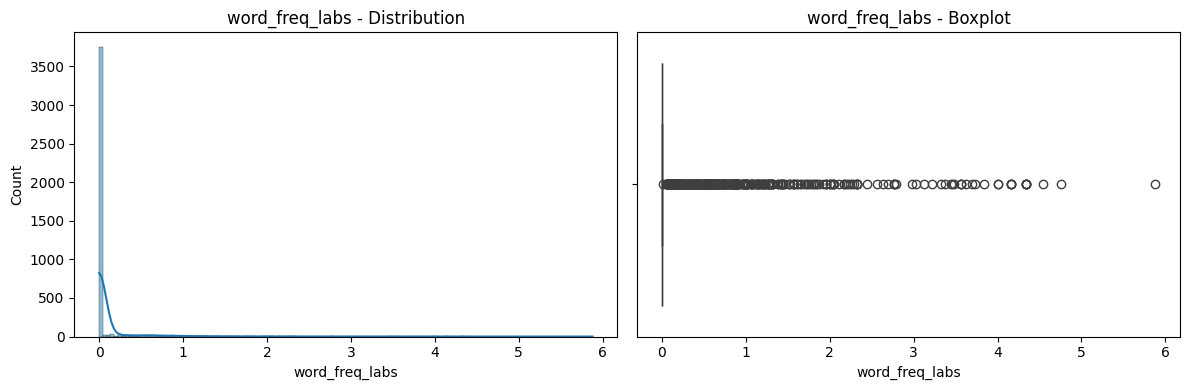

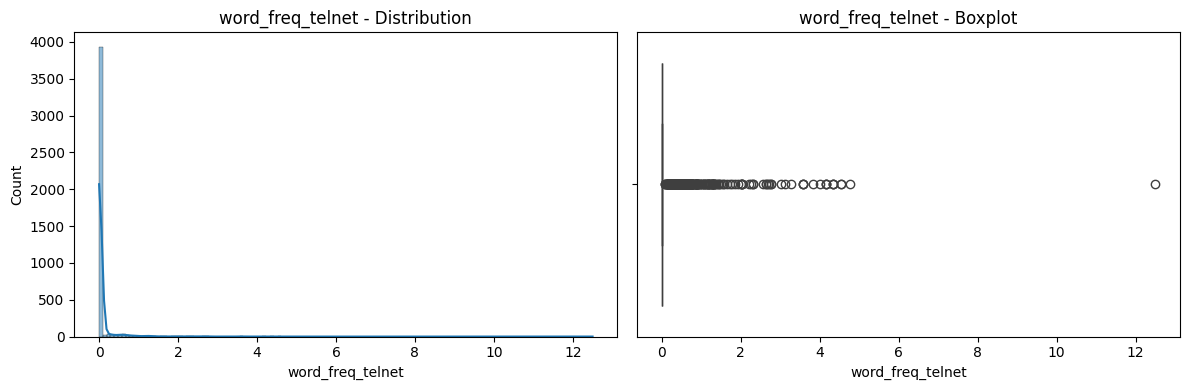

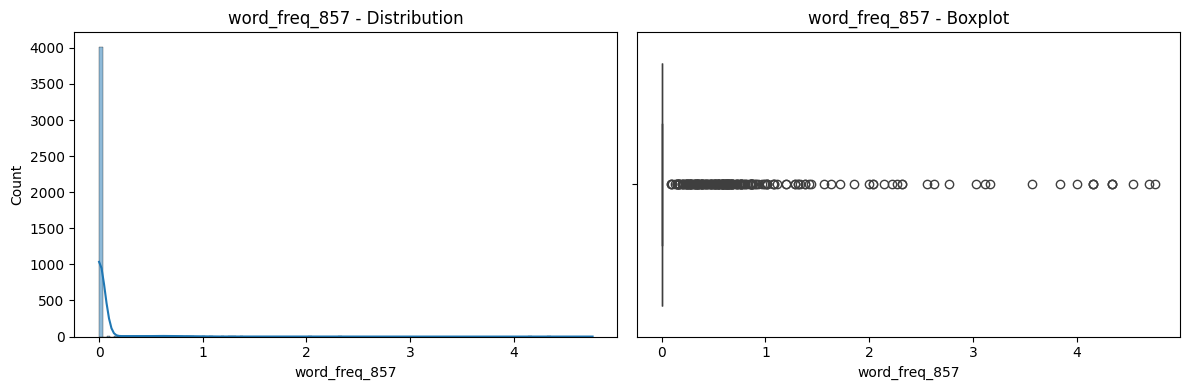

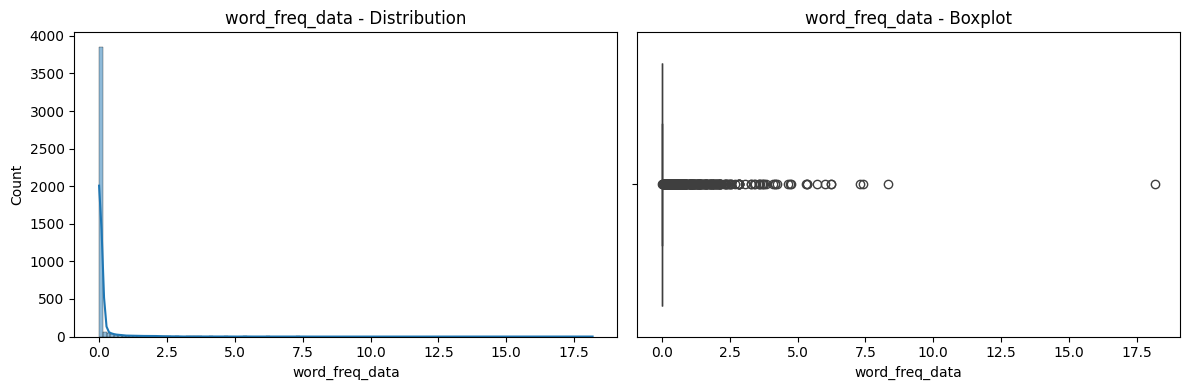

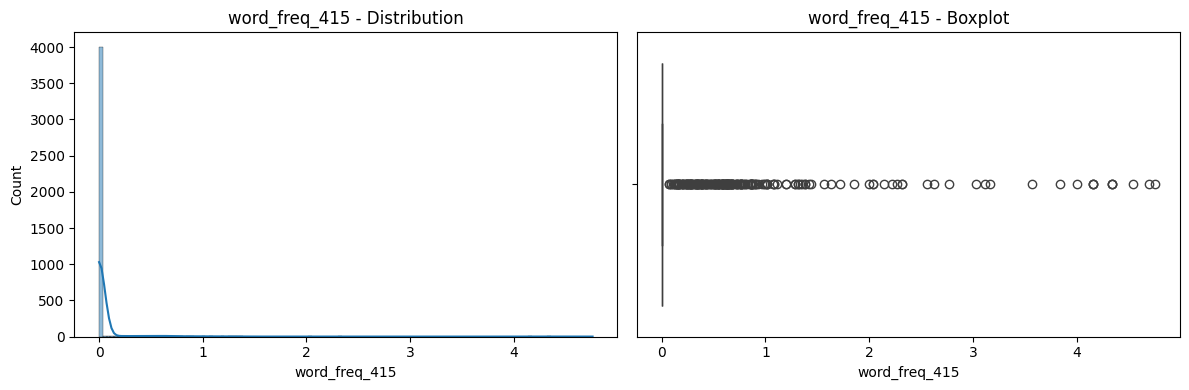

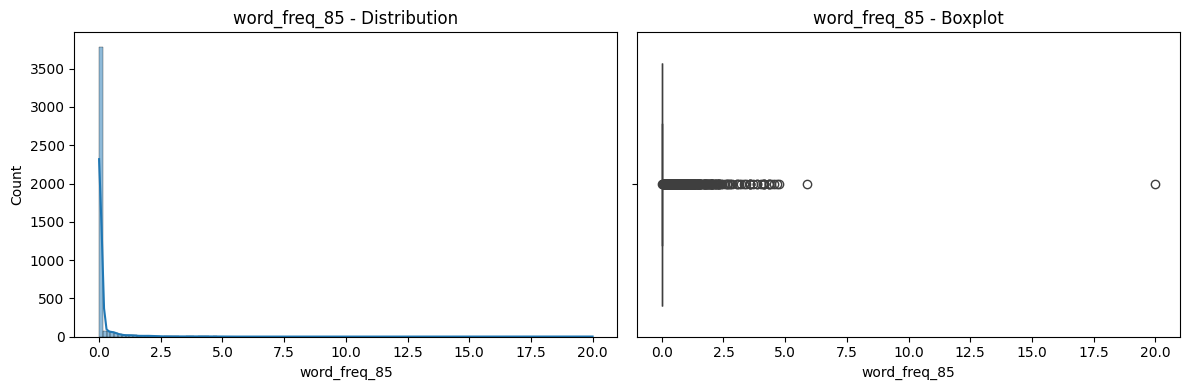

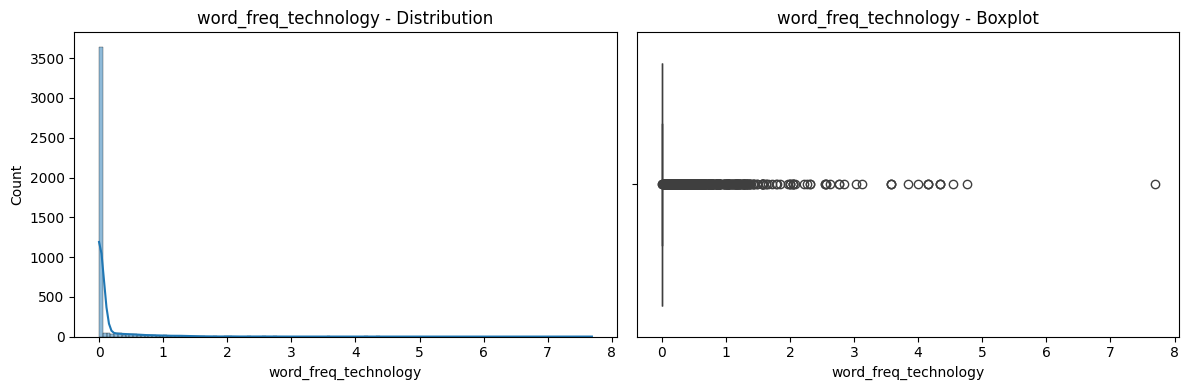

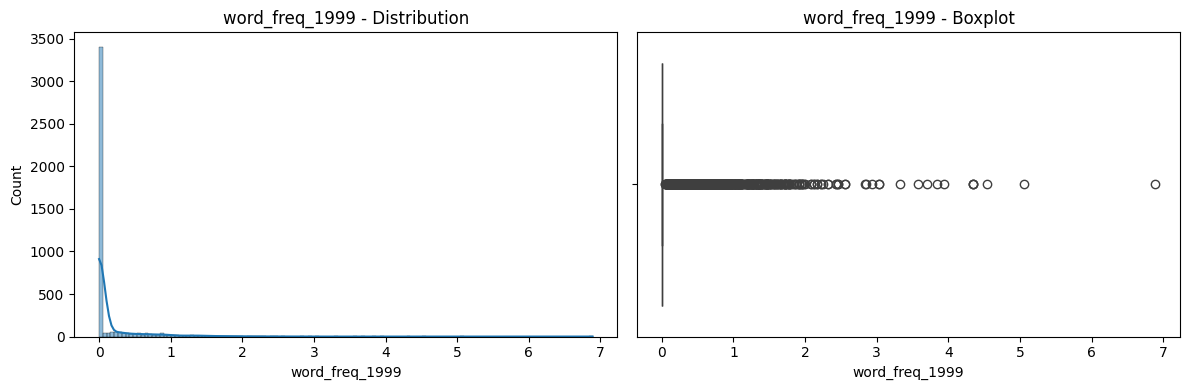

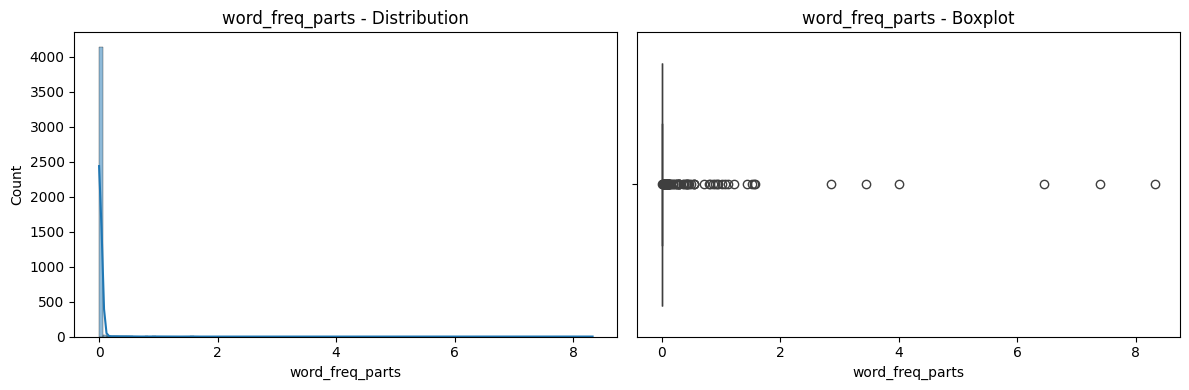

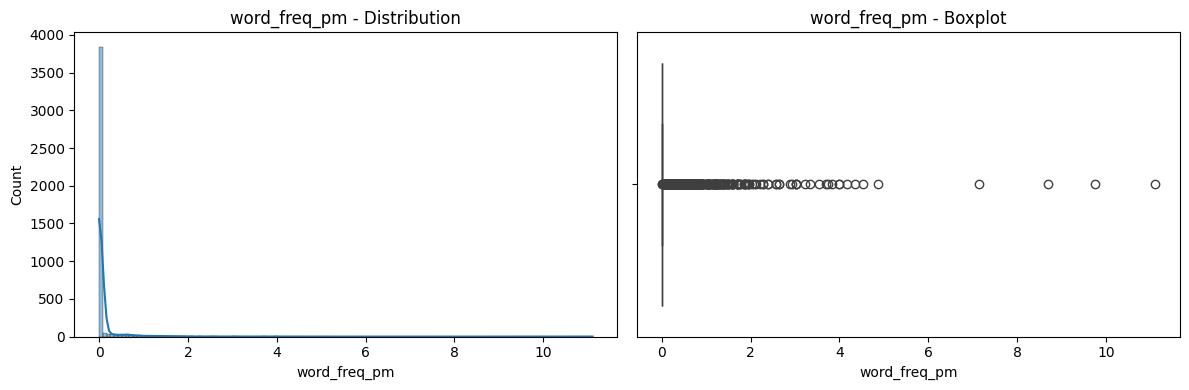

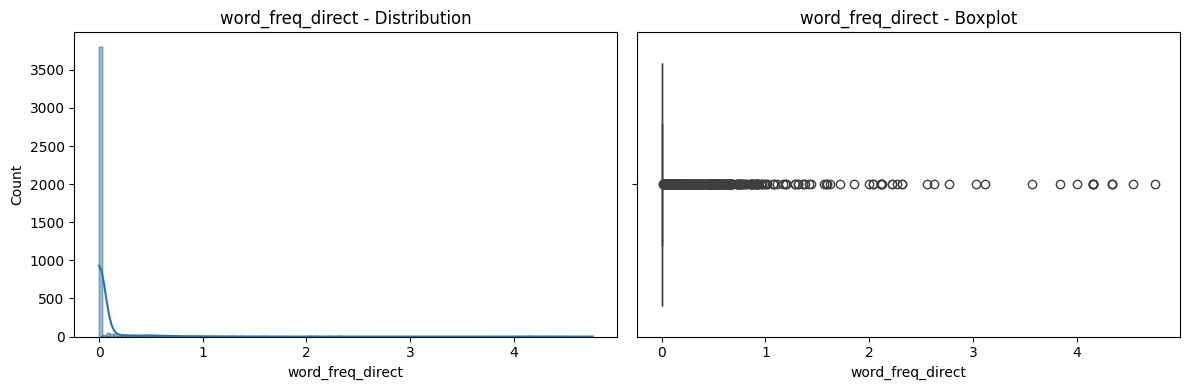

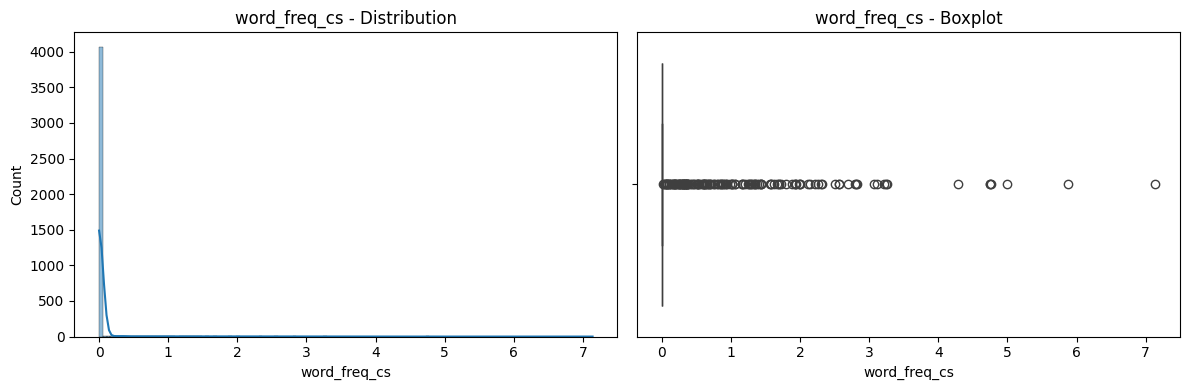

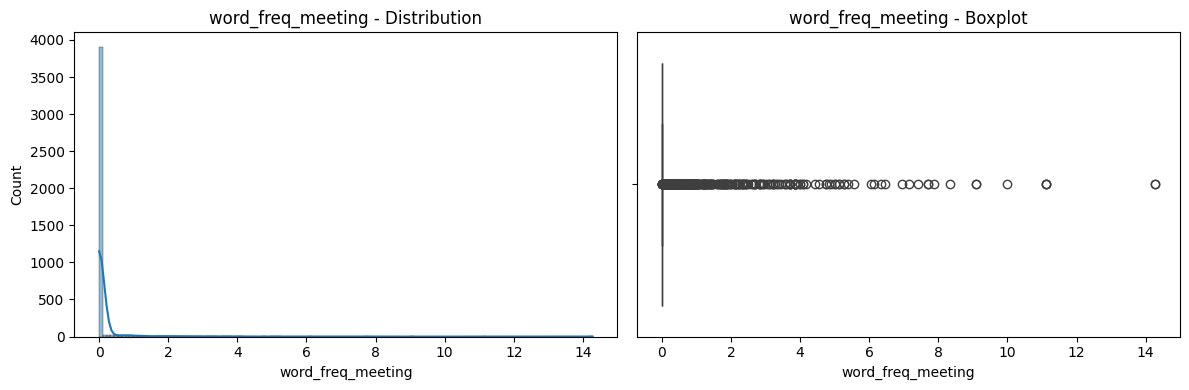

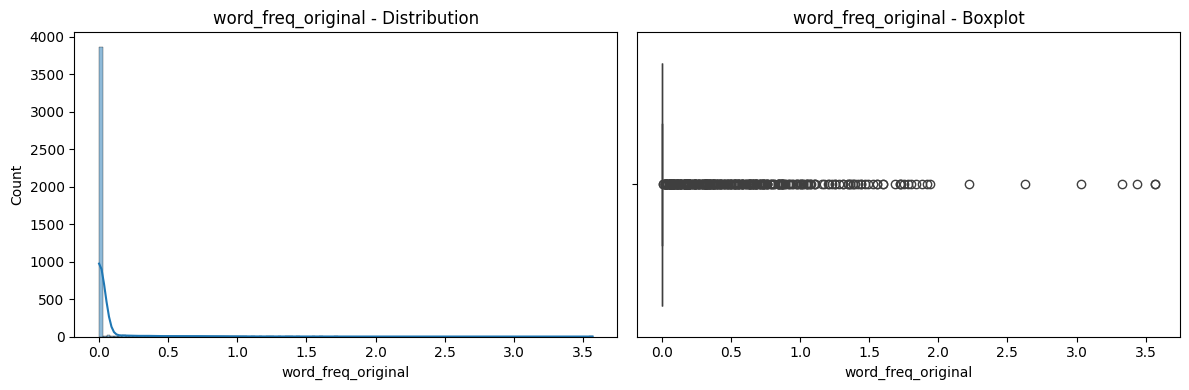

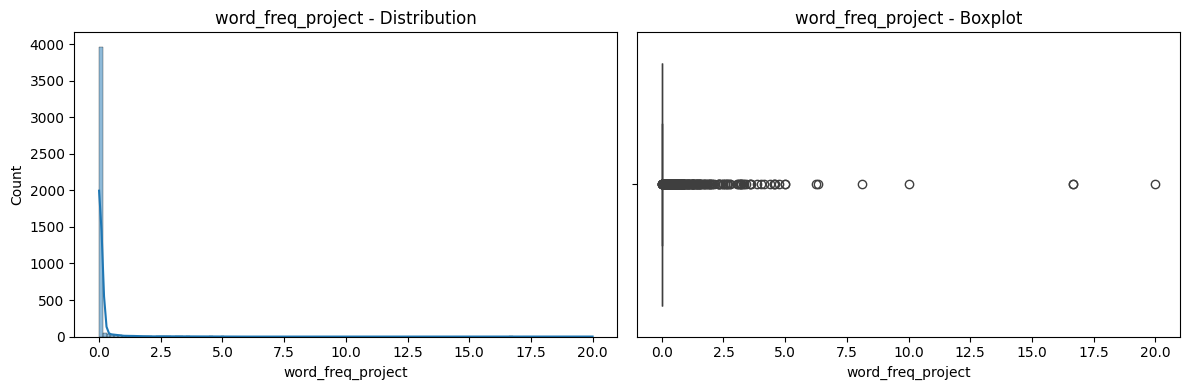

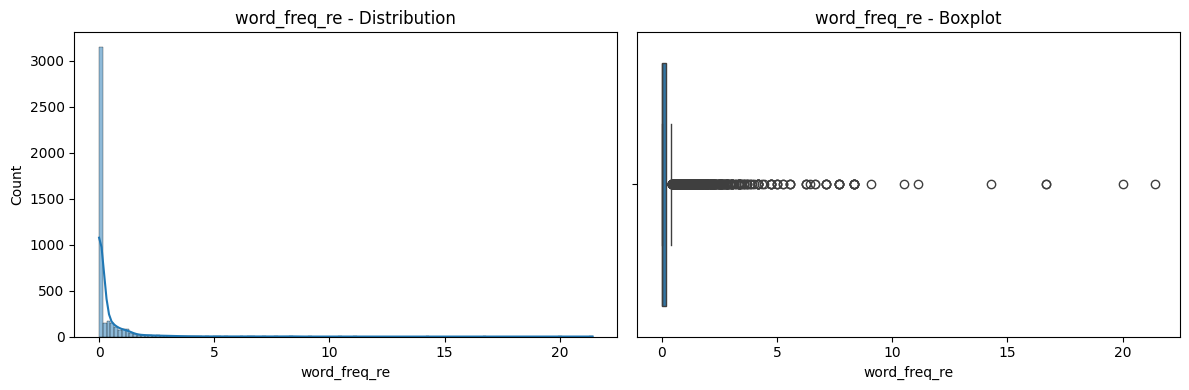

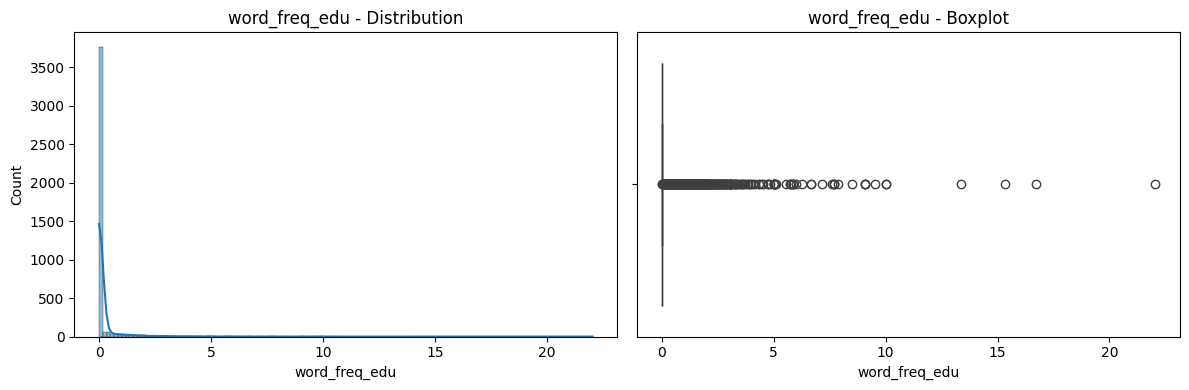

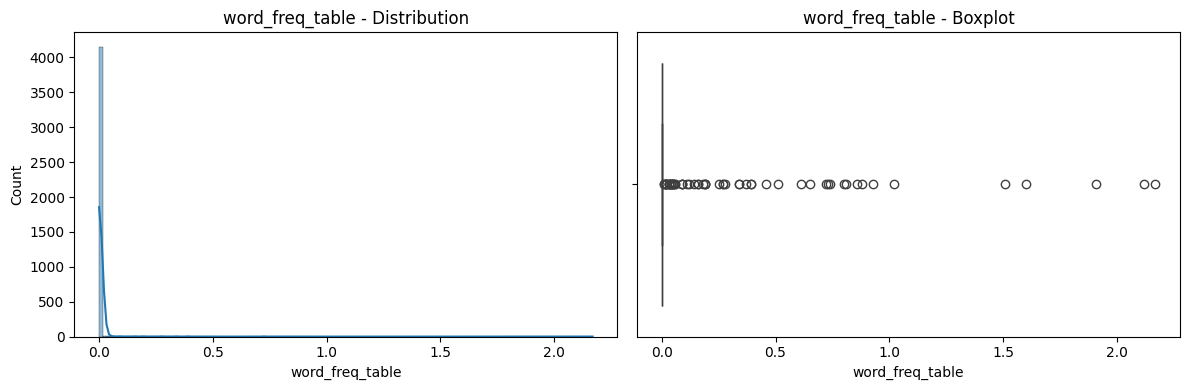

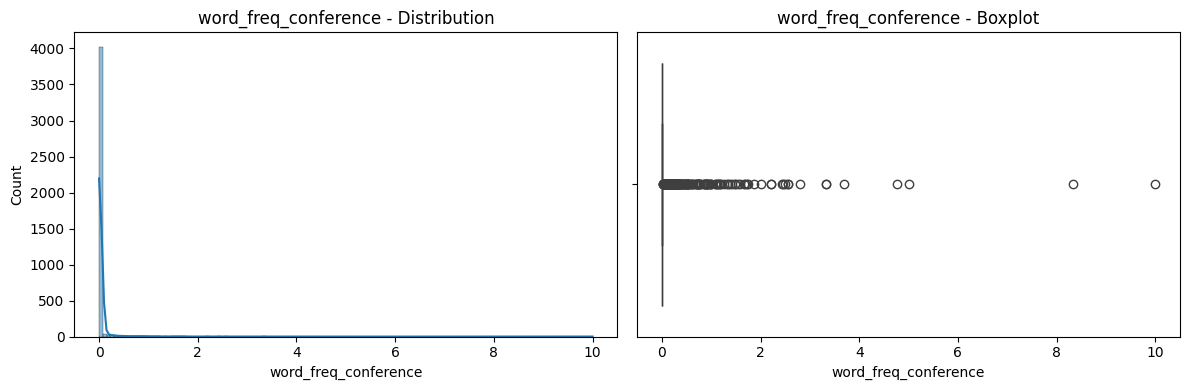

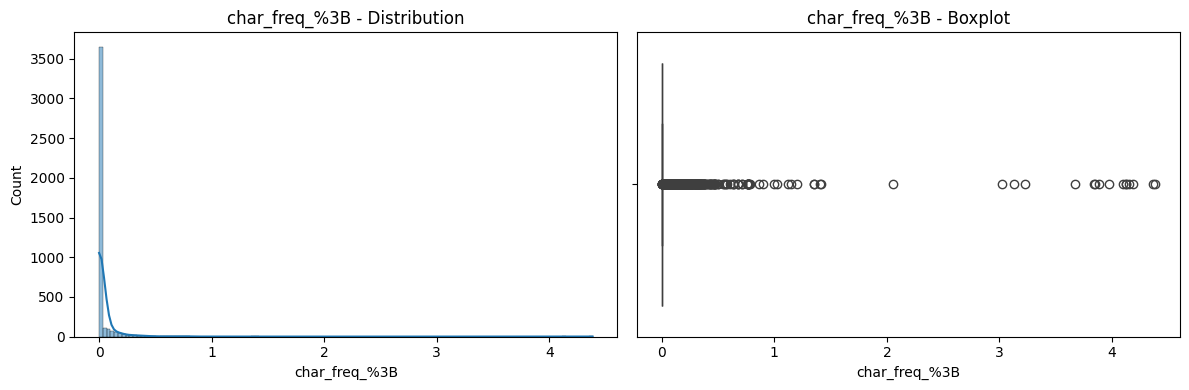

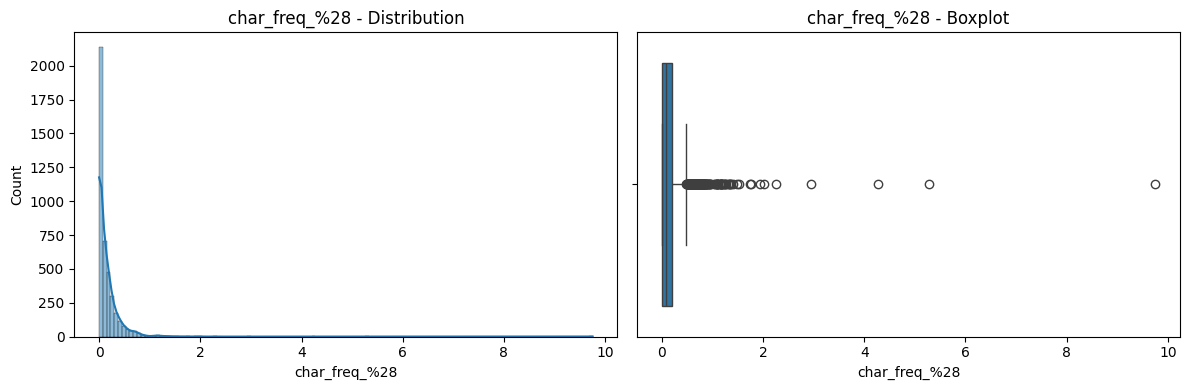

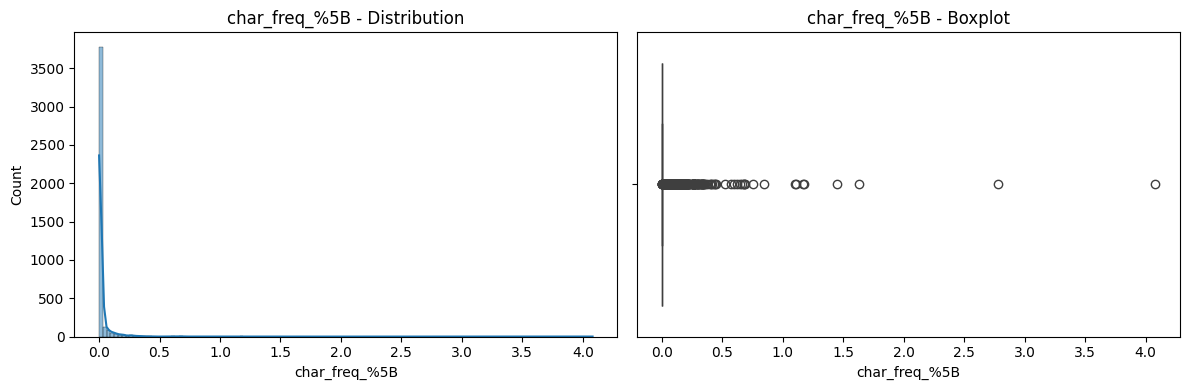

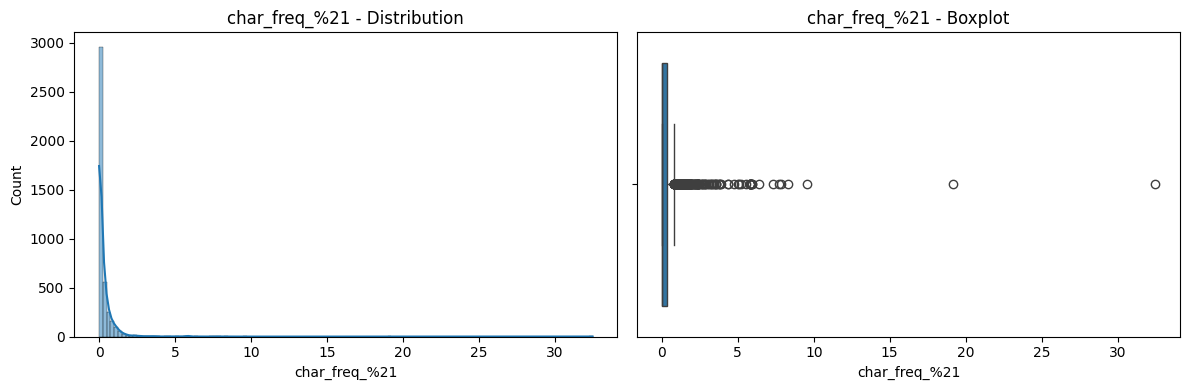

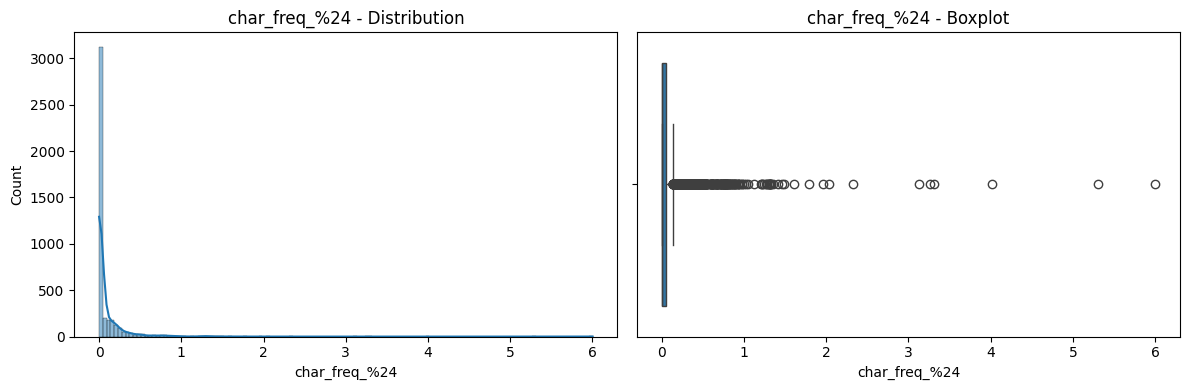

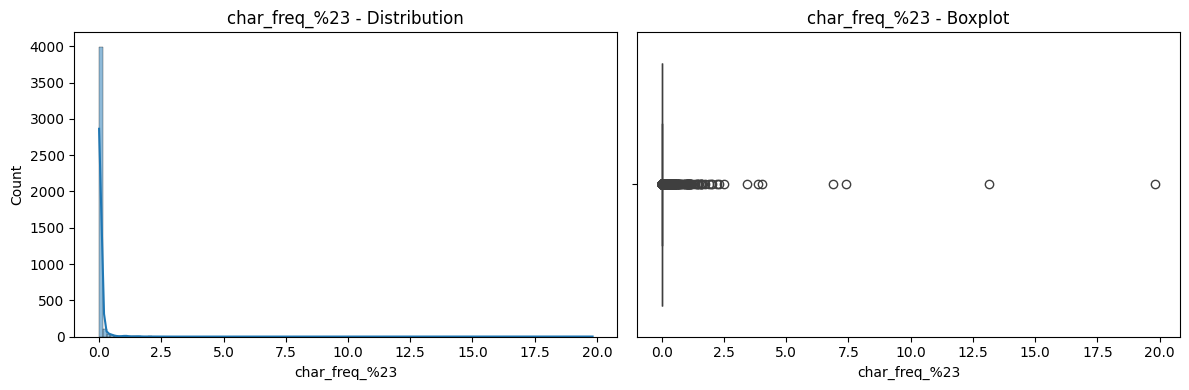

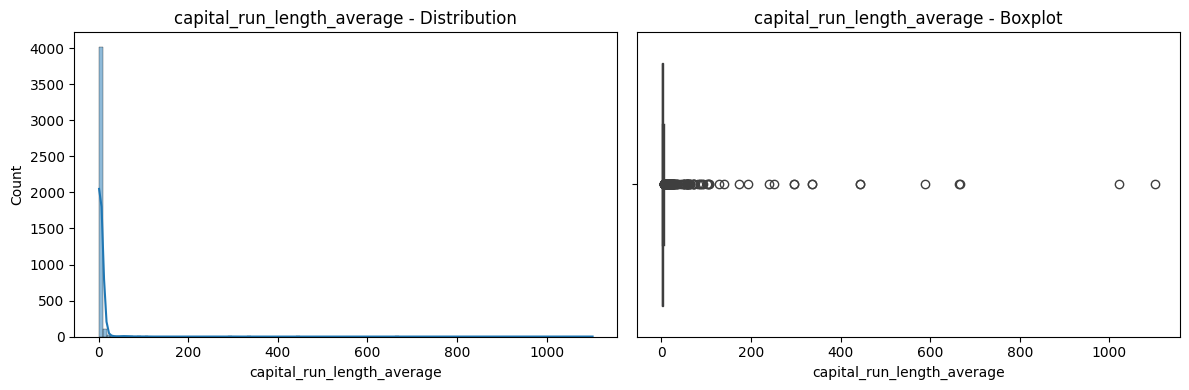

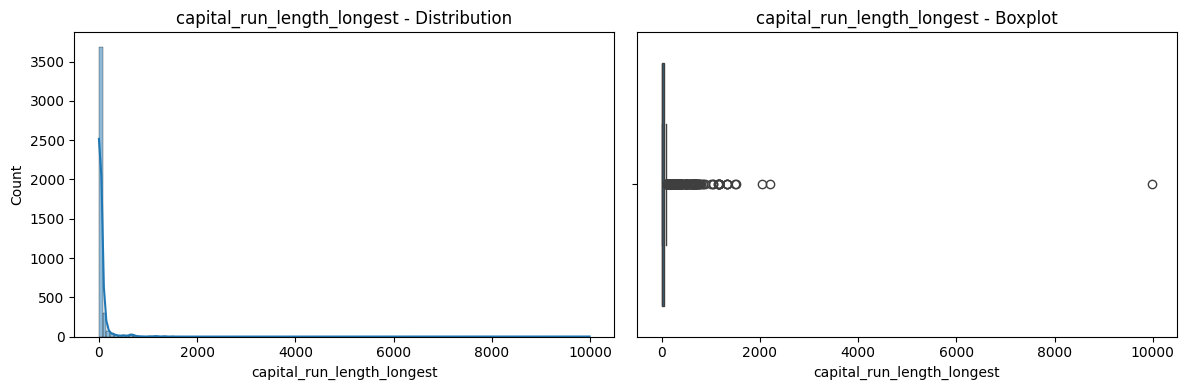

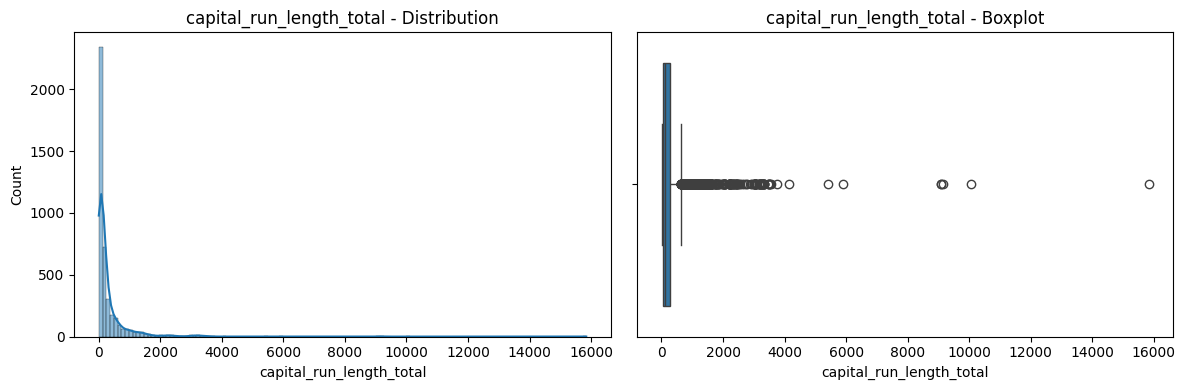

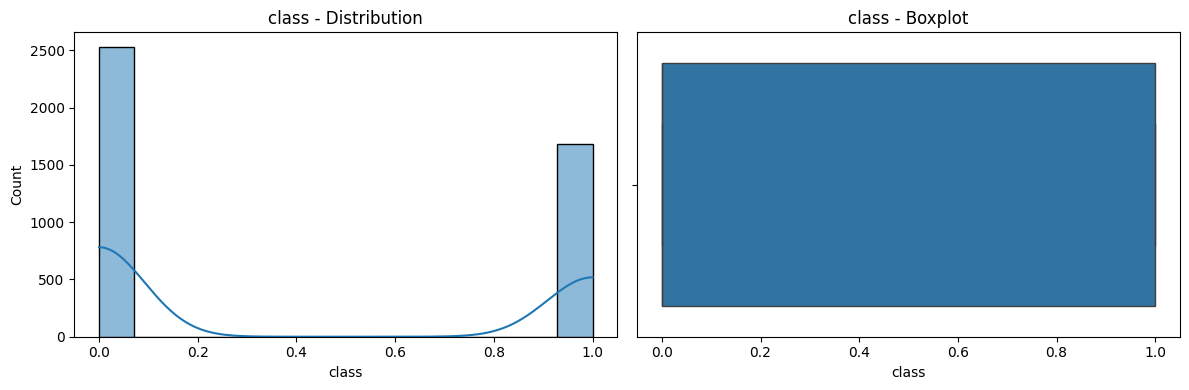

------------------------------------------------------------
CATEGORICAL FEATURE ANALYSIS
------------------------------------------------------------
CATEGORICAL ENCODING
------------------------------------------------------------
FINAL DATASET
Final dimensions: (4210, 58)
Remaining columns:
['word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d', 'word_freq_our', 'word_freq_over', 'word_freq_remove', 'word_freq_internet', 'word_freq_order', 'word_freq_mail', 'word_freq_receive', 'word_freq_will', 'word_freq_people', 'word_freq_report', 'word_freq_addresses', 'word_freq_free', 'word_freq_business', 'word_freq_email', 'word_freq_you', 'word_freq_credit', 'word_freq_your', 'word_freq_font', 'word_freq_000', 'word_freq_money', 'word_freq_hp', 'word_freq_hpl', 'word_freq_george', 'word_freq_650', 'word_freq_lab', 'word_freq_labs', 'word_freq_telnet', 'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_85', 'word_freq_technology', 'word_freq_1999', 'word_freq_pa

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

from scipy.stats import zscore
from sklearn.preprocessing import StandardScaler


def eda(df):
    print("-" * 60)
    print("DATASET OVERVIEW")

    print("Dimensions:", df.shape)
    print("\nFirst 5 rows:")
    print(df.head())

    print("\nColumns:")
    for col in df.columns:
        print(col)

    dup = df.duplicated().sum()

    print("\nDuplicate rows:", dup)

    if dup > 0:
        df = df.drop_duplicates()
        print("Duplicate rows removed.")

    print("-" * 60)
    print("MISSING VALUE ANALYSIS")

    missing = df.isnull().sum()
    missing_percentage = (df.isnull().sum() / len(df)) * 100
    print("\n")
    print(f"Number of missing values: {missing}")

    # Plot missing values
    plt.figure(figsize=(10, 5))
    plt.bar(df.columns, df.isnull().sum())
    plt.xlabel("Columns")
    plt.ylabel("Number of Missing Values")
    plt.title("Missing Values")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    
    #Remove columns with > 50% missing values
    
    missing_threshold = 50

    columns_to_drop = missing_percentage[missing_percentage > missing_threshold].index.tolist()

    if columns_to_drop:
        print("\nColumns removed because of excessive missing values:")
        for col in columns_to_drop: 
            print("column: " + col + " missing percentage: " + missing_percentage[col])
        df = df.drop(columns=columns_to_drop)

    else:
        print("\nNo columns have more than 50% missing values.")

    #Remove constant columns

    constant_columns = []    

    for col in df.columns:
            if df[col].nunique(dropna=False) <= 1:
                constant_columns.append(col)

    if constant_columns:
        print("\nConstant columns removed:")
        for col in constant_columns:
            print(col)
        df = df.drop(columns=constant_columns)

 
    #Seperate numerical and categorical features

    num_cols = df.select_dtypes(include=np.number).columns.tolist()

    cat_cols = df.select_dtypes(include=["object", "category", "string", "bool"]).columns.tolist()

    print("\nNumerical columns:")
    print(num_cols)

    print("\nCategorical columns:")
    print(cat_cols)

    
    #Missing value imputation
    
    print("-" * 60)
    print("MISSING VALUE IMPUTATION")

    for col in num_cols:
        if df[col].isnull().sum() > 0:
            median_value = df[col].median()
            df[col] = df[col].fillna(median_value)

    for col in cat_cols:
        if df[col].isnull().sum() > 0:
            mode = df[col].mode()
            if not mode.empty:
                mode_value = mode[0]
                df[col] = df[col].fillna(mode_value)

    print("Missing values imputed!")

    print("-" * 60)
    print("NUMERICAL FEATURES VISUALIZATION")
    for col in num_cols:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        sns.histplot(df[col], kde=True, ax=axes[0])
        axes[0].set_title(f"{col} - Distribution")
        axes[0].set_xlabel(col)

        sns.boxplot(x=df[col], ax=axes[1])
        axes[1].set_title(f"{col} - Boxplot")
        axes[1].set_xlabel(col)

        plt.tight_layout()
        plt.show()

    #Categorical feature analysis

    print("-" * 60)
    print("CATEGORICAL FEATURE ANALYSIS")

    for col in cat_cols:
        counts = df[col].value_counts()

        plt.figure(figsize=(8, 5))

        sns.countplot(
            data=df,
            x=col,
            order=counts.index
        )

        plt.title(f"Count Plot - {col}")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

    
    # Encode categorical values
    
    print("-" * 60)
    print("CATEGORICAL ENCODING")

    for col in cat_cols:
        unique_count = df[col].nunique()
        if unique_count == 2:
            values = df[col].unique()
            mapping = {values[0]: 0, values[1]: 1}
            df[col] = df[col].map(mapping)
            print(f"{col}: Binary encoding -> {mapping}")

        else:

            dummies = pd.get_dummies(df[col], prefix=col, drop_first=True, dtype=int)
            df = pd.concat([df.drop(columns=[col]), dummies],axis=1)
            print(f"{col}: One-hot encoded ")
            print(f"{unique_count} categories")


    # Final dataset

    print("-" * 60)
    print("FINAL DATASET")

    print("Final dimensions:", df.shape)

    print("Remaining columns:")
    print(df.columns.tolist())

    print("Remaining missing values:")
    print(df.isnull().sum())

    print("Final dataframe:")
    print(df.head())

    return df

df = pd.read_csv("spambase_csv.csv")
df = eda(df)

## 2. Train and Test Data Split

In [3]:
from sklearn.model_selection import train_test_split
x = df.drop(columns=["class"])
y = df["class"]
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)


## 3. Training baseline Linear Regression Model

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
import time
from sklearn.metrics import log_loss
start_time = time.time()
model = LogisticRegression(random_state=42,max_iter=10000)
model.fit(x_train, y_train)
training_time = time.time() - start_time
y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
y_prob = model.predict_proba(x_test)[:, 1]
bce = log_loss(y_test, y_prob)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f"Accuracy  : {accuracy}")
print(f"Binary Cross Entropy Loss : {bce}")
print(f"Precision : {precision}")
print(f"Recall    : {recall}")
print(f"F1 Score  : {f1}")
print(f"Training Time  : {training_time}")

Accuracy  : 0.9192399049881235
Binary Cross Entropy Loss : 0.20550098179284762
Precision : 0.9292035398230089
Recall    : 0.8774373259052924
F1 Score  : 0.9025787965616046
Training Time  : 2.2656192779541016


## 4. Tuning Hyperparameters using GridSearchCV

In [5]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(random_state=42,max_iter=1000)
param_grid = {'penalty': ['l1', 'l2'],'C': [0.01, 0.1, 1, 10, 100],'solver': ['liblinear', 'saga']}
grid_search = GridSearchCV(estimator=logistic_model,param_grid=param_grid,cv=5,scoring='f1',n_jobs=-1)
grid_search.fit(x_train, y_train)
print("Best Parameters:")
print(grid_search.best_params_)
print("Best CV F1 Score:")
print(grid_search.best_score_)

Best Parameters:
{'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV F1 Score:
0.8987424732677802


## 5. Training Baseline SVM with different kernels

In [6]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import log_loss
import time

# linear kernel 
start_time = time.time()
svm_model = SVC(kernel="linear",random_state=42)
svm_model.fit(x_train, y_train)
training_time = time.time() - start_time
y_pred = svm_model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Kernel         : LINEAR")
print(f"Accuracy       : {accuracy}")
print(f"Precision      : {precision}")
print(f"Recall         : {recall}")
print(f"F1 Score       : {f1}")
print(f"BCE            : {bce}")
print(f"Training Time  : {training_time}")
print("-" * 50)

# polynoimial kernel
start_time = time.time()
svm_model = SVC(kernel="poly",random_state=42)
svm_model.fit(x_train, y_train)
training_time = time.time() - start_time
y_pred = svm_model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Kernel         : POLYNOMIAL")
print(f"Accuracy       : {accuracy}")
print(f"Precision      : {precision}")
print(f"Recall         : {recall}")
print(f"F1 Score       : {f1}")
print(f"BCE            : {bce}")
print(f"Training Time  : {training_time}")
print("-" * 50)

# RBF kernel
start_time = time.time()
svm_model = SVC(kernel="rbf",random_state=42)
svm_model.fit(x_train, y_train)
training_time = time.time() - start_time
y_pred = svm_model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Kernel         : RBF")
print(f"Accuracy       : {accuracy}")
print(f"Precision      : {precision}")
print(f"Recall         : {recall}")
print(f"F1 Score       : {f1}")
print(f"BCE            : {bce}")
print(f"Training Time  : {training_time}")
print("-" * 50)

# Sigmoid Kernel
start_time = time.time()
svm_model = SVC(kernel="sigmoid",random_state=42)
svm_model.fit(x_train, y_train)
training_time = time.time() - start_time
y_pred = svm_model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Kernel         : SIGMOID")
print(f"Accuracy       : {accuracy}")
print(f"Precision      : {precision}")
print(f"Recall         : {recall}")
print(f"F1 Score       : {f1}")
print(f"BCE            : {bce}")
print(f"Training Time  : {training_time}")
print("-" * 50)

Kernel         : LINEAR
Accuracy       : 0.9228028503562945
Precision      : 0.9248554913294798
Recall         : 0.8913649025069638
F1 Score       : 0.9078014184397163
BCE            : 0.20550098179284762
Training Time  : 174.84140253067017
--------------------------------------------------
Kernel         : POLYNOMIAL
Accuracy       : 0.6104513064133017
Precision      : 0.8604651162790697
Recall         : 0.10306406685236769
F1 Score       : 0.18407960199004975
BCE            : 0.20550098179284762
Training Time  : 1.0375947952270508
--------------------------------------------------
Kernel         : RBF
Accuracy       : 0.6852731591448931
Precision      : 0.7447916666666666
Recall         : 0.3983286908077994
F1 Score       : 0.5190562613430127
BCE            : 0.20550098179284762
Training Time  : 0.5248250961303711
--------------------------------------------------
Kernel         : SIGMOID
Accuracy       : 0.6187648456057007
Precision      : 0.5558823529411765
Recall         : 0.52646

## 6. Tuning Hyperparametrs of SVM using GridSearchCV

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

svm = SVC(random_state=42)

param_grid = [
    {
        'kernel': ['linear'],
        'C': [0.1, 1, 10]
    },

    {
        'kernel': ['rbf'],
        'C': [0.1, 1, 10],
        'gamma': ['scale', 0.01, 0.1]
    },

    {
        'kernel': ['poly'],
        'C': [0.1, 1, 10],
        'gamma': ['scale', 0.01],
        'degree': [2, 3]
    },

    {
        'kernel': ['sigmoid'],
        'C': [0.1, 1, 10],
        'gamma': ['scale', 0.01]
    }
]
grid_search = GridSearchCV(estimator=svm,param_grid=param_grid,cv=3,scoring='accuracy',n_jobs=-1,verbose=1)
grid_search.fit(x_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("Best CV Accuracy:")
print(grid_search.best_score_)

Fitting 3 folds for each of 30 candidates, totalling 90 fits


## 7. 5-Fold Cross Validation

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate
cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
logist_model = LogisticRegression(max_iter = 1000, random_state=42)
start_time = time.time()
logistic_cv = cross_validate(logist_model,x_train,y_train,cv=5,scoring="accuracy",n_jobs=-1)
logistic_cv_time = time.time() - start_time
fold_scores = logistic_cv["test_score"]
print("SCORES FOR LOGISTIC REGRESSION")
for i in range(len(fold_scores)):
    print(f"Fold {i+1} Accuracy: {fold_scores[i]}")
print(f"Mean Accuracy: {fold_scores.mean()}")
print(f"Training Time : {logistic_cv_time}")
print("-" * 50)
svm_model = SVC(kernel = "linear",random_state = 42)
start_time = time.time()
svm_cv = cross_validate(svm_model,x_train,y_train,cv=5,scoring="accuracy",n_jobs=-1)
svm_cv_time = time.time() - start_time
fold_scores_svm = svm_cv["test_score"]
print("SCORES FOR SVM MODEL")
for i in range(len(fold_scores_svm)):
    print(f"Fold {i+1} Accuracy: {fold_scores_svm[i]}")
print(f"Mean Accuracy: {fold_scores_svm.mean()}")
print(f"Training Time : {svm_cv_time}")
print("-" * 50)

SCORES FOR LOGISTIC REGRESSION
Fold 1 Accuracy: 0.9109792284866469
Fold 2 Accuracy: 0.9109792284866469
Fold 3 Accuracy: 0.9258160237388724
Fold 4 Accuracy: 0.9227340267459139
Fold 5 Accuracy: 0.9316493313521546
Mean Accuracy: 0.9204315677620469
Training Time : 7.332457780838013
--------------------------------------------------
SCORES FOR SVM MODEL
Fold 1 Accuracy: 0.9124629080118695
Fold 2 Accuracy: 0.913946587537092
Fold 3 Accuracy: 0.9317507418397626
Fold 4 Accuracy: 0.9271916790490342
Fold 5 Accuracy: 0.9361069836552749
Mean Accuracy: 0.9242917800186067
Training Time : 544.8326897621155
--------------------------------------------------
